### Comparación LSTM vs GRU — Predicción de Series Temporales
#### Caso de Estudio: Cotización USD → BRL

| # | Sección |
|---|---|
| 1 | Importación de librerías y carga del dataset |
| 2 | Normalización y ventanas deslizantes |
| 3 | División cronológica y DataLoaders |
| 4 | Pipeline de entrenamiento compartido |
| 5 | Modelo LSTM |
| 6 | Modelo GRU |
| 7 | Evaluación desnormalizada en BRL |
| 8 | Gráfica comparativa |
| 9 | Tabla de resultados finales |

#### 1. Importación de Librerías y Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión : {torch.__version__}')
print(f'Dispositivo     : {"cuda" if torch.cuda.is_available() else "cpu"}')

Librerías cargadas correctamente.
PyTorch versión : 2.5.1
Dispositivo     : cuda


In [2]:
# ── Ajusta esta ruta si es necesario ──────────────────────────────────────────
ruta_csv = r'D:\2026\IA-2026-DATASETS\USD_BRL Historical Data.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(ruta_csv)
df = df[['Date', 'Price']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print(f'Registros totales : {len(df)}')
print(f'Rango de fechas   : {df["Date"].min().date()} -> {df["Date"].max().date()}')
print(f'Precio min / max  : {df["Price"].min():.4f} / {df["Price"].max():.4f} BRL')
df.head()

Registros totales : 2922
Rango de fechas   : 2015-01-01 -> 2026-03-13
Precio min / max  : 2.5722 / 6.2896 BRL


,Date,Price
0,2015-01-01,2.6570
1,2015-01-02,2.6931
2,2015-01-05,2.7059
3,2015-01-06,2.6996
4,2015-01-07,2.6830


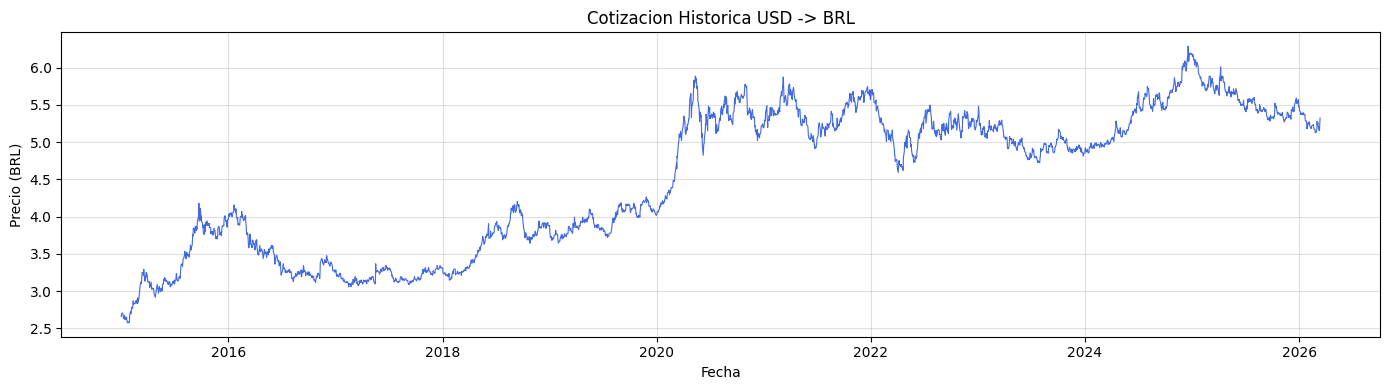

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotizacion Historica USD -> BRL')
plt.xlabel('Fecha'); plt.ylabel('Precio (BRL)')
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

#### 2. Normalización y Ventanas Deslizantes

> **Regla de corrección de escala:** el `MinMaxScaler` se ajusta sobre los precios originales en BRL. En la evaluación, `scaler.inverse_transform()` revierte las predicciones [0,1] de vuelta a BRL para calcular MSE y RMSE en la escala real.

In [4]:
N_STEPS    = 50
BATCH_SIZE = 64

# MinMaxScaler ajustado sobre precios en BRL — se reutiliza en evaluacion
precios_raw  = df['Price'].values.reshape(-1, 1)
scaler       = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios_raw).flatten()

print(f'Rango normalizado : [{precios_norm.min():.4f}, {precios_norm.max():.4f}]')
print(f'Scaler min_       : {scaler.data_min_[0]:.4f} BRL')
print(f'Scaler max_       : {scaler.data_max_[0]:.4f} BRL')


def crear_ventanas(serie, n_steps):
    """
    Convierte una serie 1D normalizada en ventanas para LSTM/GRU.
    X : (N-n_steps, n_steps, 1)  <- tensor 3D requerido por nn.LSTM y nn.GRU
    y : (N-n_steps, 1)
    """
    X, y = [], []
    for i in range(len(serie) - n_steps):
        X.append(serie[i : i + n_steps])
        y.append(serie[i + n_steps])
    X = np.array(X, dtype=np.float32)[:, :, np.newaxis]  # anadir dim feature
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    return X, y


X_all, y_all = crear_ventanas(precios_norm, N_STEPS)
print(f'\nX_all : {X_all.shape}  -> (muestras, n_steps, features)')
print(f'y_all : {y_all.shape}  -> (muestras, 1)')

Rango normalizado : [0.0000, 1.0000]
Scaler min_       : 2.5722 BRL
Scaler max_       : 6.2896 BRL

X_all : (2872, 50, 1)  -> (muestras, n_steps, features)
y_all : (2872, 1)  -> (muestras, 1)


#### 3. Division Cronologica y DataLoaders

In [5]:
n_total = len(X_all)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],              y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],        y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]:>5} muestras  X={X_train.shape}')
print(f'Val   : {X_val.shape[0]:>5} muestras  X={X_val.shape}')
print(f'Test  : {X_test.shape[0]:>5} muestras  X={X_test.shape}')


class TimeSeriesDataset(Dataset):
    """Dataset generico para LSTM/GRU — entrada 3D (n_steps, 1)."""
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):  return len(self.X)

    def __getitem__(self, ix):
        return (self.X[ix], self.y[ix]) if self.y is not None else self.X[ix]


dataloader = {
    'train': DataLoader(TimeSeriesDataset(X_train, y_train), shuffle=True,  batch_size=BATCH_SIZE),
    'eval' : DataLoader(TimeSeriesDataset(X_val,   y_val),   shuffle=False, batch_size=BATCH_SIZE),
    'test' : DataLoader(TimeSeriesDataset(X_test),            shuffle=False, batch_size=BATCH_SIZE),
}

Xb, yb = next(iter(dataloader['train']))
print(f'\nBatch X : {Xb.shape}  -> (batch, n_steps, features)')
print(f'Batch y : {yb.shape}  -> (batch, 1)')

Train :  2010 muestras  X=(2010, 50, 1)
Val   :   430 muestras  X=(430, 50, 1)
Test  :   432 muestras  X=(432, 50, 1)

Batch X : torch.Size([64, 50, 1])  -> (batch, n_steps, features)
Batch y : torch.Size([64, 1])  -> (batch, 1)


#### 4. Pipeline de Entrenamiento Compartido

Ambos modelos usan exactamente las mismas funciones `fit` y `predict` para garantizar una comparacion justa.

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


def fit(model, dataloader, epochs=50, lr=1e-3):
    """Ciclo de entrenamiento con Adam + MSELoss. Retorna historiales de perdida."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    hist_train, hist_val = [], []
    bar = tqdm(range(1, epochs + 1), desc=model.__class__.__name__)

    for epoch in bar:
        # Entrenamiento
        model.train()
        batch_losses = []
        for X_b, y_b in dataloader['train']:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # Validacion
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_b, y_b in dataloader['eval']:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_losses.append(criterion(model(X_b), y_b).item())

        tl, vl = np.mean(batch_losses), np.mean(val_losses)
        hist_train.append(tl); hist_val.append(vl)
        bar.set_description(f'{model.__class__.__name__}  loss {tl:.5f}  val {vl:.5f}')

    return hist_train, hist_val


def predict(model, dl):
    """Inferencia sobre un DataLoader completo. Retorna array NumPy (N, 1)."""
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in dl:
            X = batch.to(device) if not isinstance(batch, (list, tuple)) else batch[0].to(device)
            preds.append(model(X).cpu().numpy())
    return np.concatenate(preds)


def desnormalizar(arr_norm):
    """
    CORRECCION DE ESCALA — aplicar SIEMPRE antes de calcular metricas.
    Convierte predicciones de [0, 1] de vuelta a BRL usando scaler.inverse_transform().
    """
    return scaler.inverse_transform(arr_norm.reshape(-1, 1)).flatten()


def contar_parametros(model):
    """Total de parametros entrenables del modelo."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print('Pipeline definido. Funciones: fit | predict | desnormalizar | contar_parametros')

Pipeline definido. Funciones: fit | predict | desnormalizar | contar_parametros


#### 5. Modelo LSTM

La LSTM mantiene **dos estados** por capa: $h_t$ (short-term) y $c_t$ (long-term).
Por eso su `forward()` desempaqueta la tupla `(h_n, c_n)` al llamar a `self.lstm(x)`.

```
Entrada : (batch, 50, 1)
    ↓
nn.LSTM(input=1, hidden=64, layers=2, dropout=0.2)
    |_ devuelve: out, (h_n, c_n)   <- TUPLA de dos estados
out[:, -1, :]  → ultimo paso temporal  (batch, 64)
    ↓
nn.Linear(64 → 1)
    ↓
Salida : (batch, 1)
```

In [7]:
class LSTMModel(nn.Module):
    """
    LSTM de 2 capas para prediccion one-step-ahead.

    Diferencia critica vs GRU:
    nn.LSTM devuelve (out, (h_n, c_n)) — una TUPLA de dos estados ocultos.
    El forward() DEBE desempaquetar ambos aunque solo usemos 'out'.
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True           # (batch, seq, features)
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x          : (batch, n_steps, 1)
        # out        : (batch, n_steps, hidden_size)
        # h_n        : (num_layers, batch, hidden_size) — estado corto plazo
        # c_n        : (num_layers, batch, hidden_size) — estado largo plazo
        out, (h_n, c_n) = self.lstm(x)    # <- LSTM devuelve TUPLA (h_n, c_n)
        last = out[:, -1, :]               # ultimo paso temporal (batch, hidden)
        return self.fc(last)               # (batch, 1)


lstm_model = LSTMModel()
print(lstm_model)
params_lstm = contar_parametros(lstm_model)
print(f'\nParametros entrenables (LSTM) : {params_lstm:,}')

with torch.no_grad():
    out_test = lstm_model(torch.randn(8, N_STEPS, 1))
    print(f'Verificacion dimensiones      : entrada (8,50,1) -> salida {out_test.shape}')

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parametros entrenables (LSTM) : 50,497
Verificacion dimensiones      : entrada (8,50,1) -> salida torch.Size([8, 1])


In [8]:
hist_train_lstm, hist_val_lstm = fit(lstm_model, dataloader, epochs=50)

LSTMModel  loss 0.00056  val 0.00027: 100%|██████████| 50/50 [00:07<00:00,  6.30it/s]


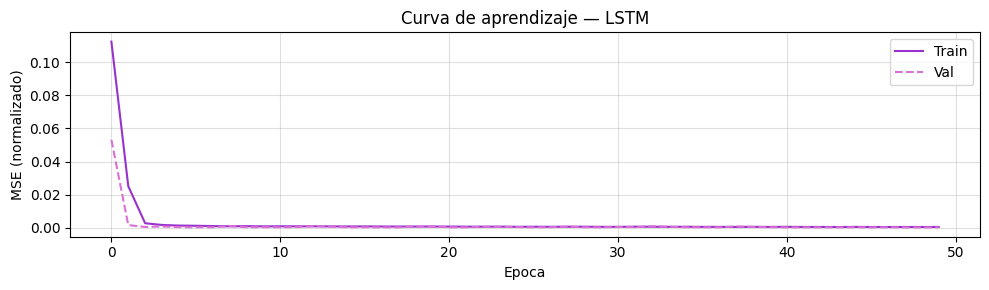

In [9]:
plt.figure(figsize=(10, 3))
plt.plot(hist_train_lstm, label='Train', color='darkorchid')
plt.plot(hist_val_lstm,   label='Val',   color='orchid', linestyle='--')
plt.title('Curva de aprendizaje — LSTM')
plt.xlabel('Epoca'); plt.ylabel('MSE (normalizado)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

#### 6. Modelo GRU

La GRU simplifica la LSTM con **un solo estado oculto** $h_t$, sin estado de celda $c_t$.
Usa 2 puertas (update + reset) en lugar de 4, reduciendo los parametros ~25%.

```
Entrada : (batch, 50, 1)
    ↓
nn.GRU(input=1, hidden=64, layers=2, dropout=0.2)
    |_ devuelve: out, h_n   <- SIN c_n (no hay estado de celda)
out[:, -1, :]  → ultimo paso temporal  (batch, 64)
    ↓
nn.Linear(64 → 1)
    ↓
Salida : (batch, 1)
```

In [10]:
class GRUModel(nn.Module):
    """
    GRU de 2 capas para prediccion one-step-ahead.

    Diferencia critica vs LSTM:
    nn.GRU NO tiene estado de celda (c_t).
    El forward() recibe solo h_n directamente — NO una tupla (h_n, c_n).
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True           # (batch, seq, features)
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x    : (batch, n_steps, 1)
        # out  : (batch, n_steps, hidden_size)
        # h_n  : (num_layers, batch, hidden_size)  <- solo UN estado, no tupla
        out, h_n = self.gru(x)            # <- GRU devuelve h_n directamente (sin c_n)
        last = out[:, -1, :]              # ultimo paso temporal (batch, hidden)
        return self.fc(last)              # (batch, 1)


gru_model = GRUModel()
print(gru_model)
params_gru = contar_parametros(gru_model)
print(f'\nParametros entrenables (GRU)  : {params_gru:,}')

with torch.no_grad():
    out_test = gru_model(torch.randn(8, N_STEPS, 1))
    print(f'Verificacion dimensiones      : entrada (8,50,1) -> salida {out_test.shape}')

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parametros entrenables (GRU)  : 37,889
Verificacion dimensiones      : entrada (8,50,1) -> salida torch.Size([8, 1])


In [11]:
hist_train_gru, hist_val_gru = fit(gru_model, dataloader, epochs=50)

GRUModel  loss 0.00040  val 0.00024: 100%|██████████| 50/50 [00:07<00:00,  6.84it/s]


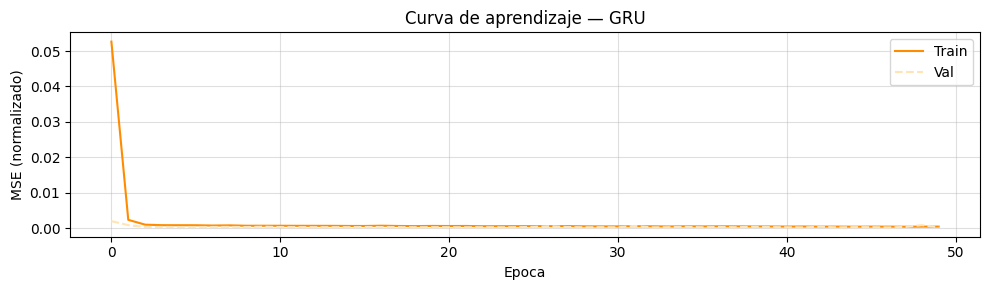

In [12]:
plt.figure(figsize=(10, 3))
plt.plot(hist_train_gru, label='Train', color='darkorange')
plt.plot(hist_val_gru,   label='Val',   color='moccasin', linestyle='--')
plt.title('Curva de aprendizaje — GRU')
plt.xlabel('Epoca'); plt.ylabel('MSE (normalizado)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

#### 7. Evaluacion Desnormalizada en BRL

> **Regla de correccion de escala (aplicada aqui):**  
> Se llama a `scaler.inverse_transform()` sobre **predicciones Y valores reales** antes de calcular cualquier metrica. MSE y RMSE se expresan en Reales Brasileños (BRL), nunca en la escala [0, 1].

In [13]:
# ── 1. Predicciones en escala normalizada [0, 1] ──────────────────────────────
y_pred_lstm_norm = predict(lstm_model, dataloader['test'])   # (N_test, 1)
y_pred_gru_norm  = predict(gru_model,  dataloader['test'])   # (N_test, 1)

# ── 2. CORRECCION DE ESCALA: inverse_transform -> BRL ─────────────────────────
# Aplicar a: valores reales, predicciones LSTM, predicciones GRU y Naive
y_test_brl       = desnormalizar(y_test)              # valores reales en BRL
y_pred_lstm_brl  = desnormalizar(y_pred_lstm_norm)    # LSTM en BRL
y_pred_gru_brl   = desnormalizar(y_pred_gru_norm)     # GRU  en BRL

# Naive: ultimo valor de la ventana (X_test[:, -1, 0])
y_pred_naive_norm = X_test[:, -1, 0].reshape(-1, 1)
y_pred_naive_brl  = desnormalizar(y_pred_naive_norm)  # Naive en BRL

# ── 3. MSE y RMSE en BRL ──────────────────────────────────────────────────────
mse_naive  = mean_squared_error(y_test_brl, y_pred_naive_brl)
mse_lstm   = mean_squared_error(y_test_brl, y_pred_lstm_brl)
mse_gru    = mean_squared_error(y_test_brl, y_pred_gru_brl)

rmse_naive = np.sqrt(mse_naive)
rmse_lstm  = np.sqrt(mse_lstm)
rmse_gru   = np.sqrt(mse_gru)

print('Errores en escala real (BRL) — post inverse_transform():')
print(f'  Naive  -> MSE: {mse_naive:.6f}  |  RMSE: {rmse_naive:.4f} BRL')
print(f'  LSTM   -> MSE: {mse_lstm:.6f}  |  RMSE: {rmse_lstm:.4f} BRL')
print(f'  GRU    -> MSE: {mse_gru:.6f}  |  RMSE: {rmse_gru:.4f} BRL')

Errores en escala real (BRL) — post inverse_transform():
  Naive  -> MSE: 0.001943  |  RMSE: 0.0441 BRL
  LSTM   -> MSE: 0.007076  |  RMSE: 0.0841 BRL
  GRU    -> MSE: 0.002914  |  RMSE: 0.0540 BRL


#### 8. Grafica Comparativa: LSTM vs GRU vs Real

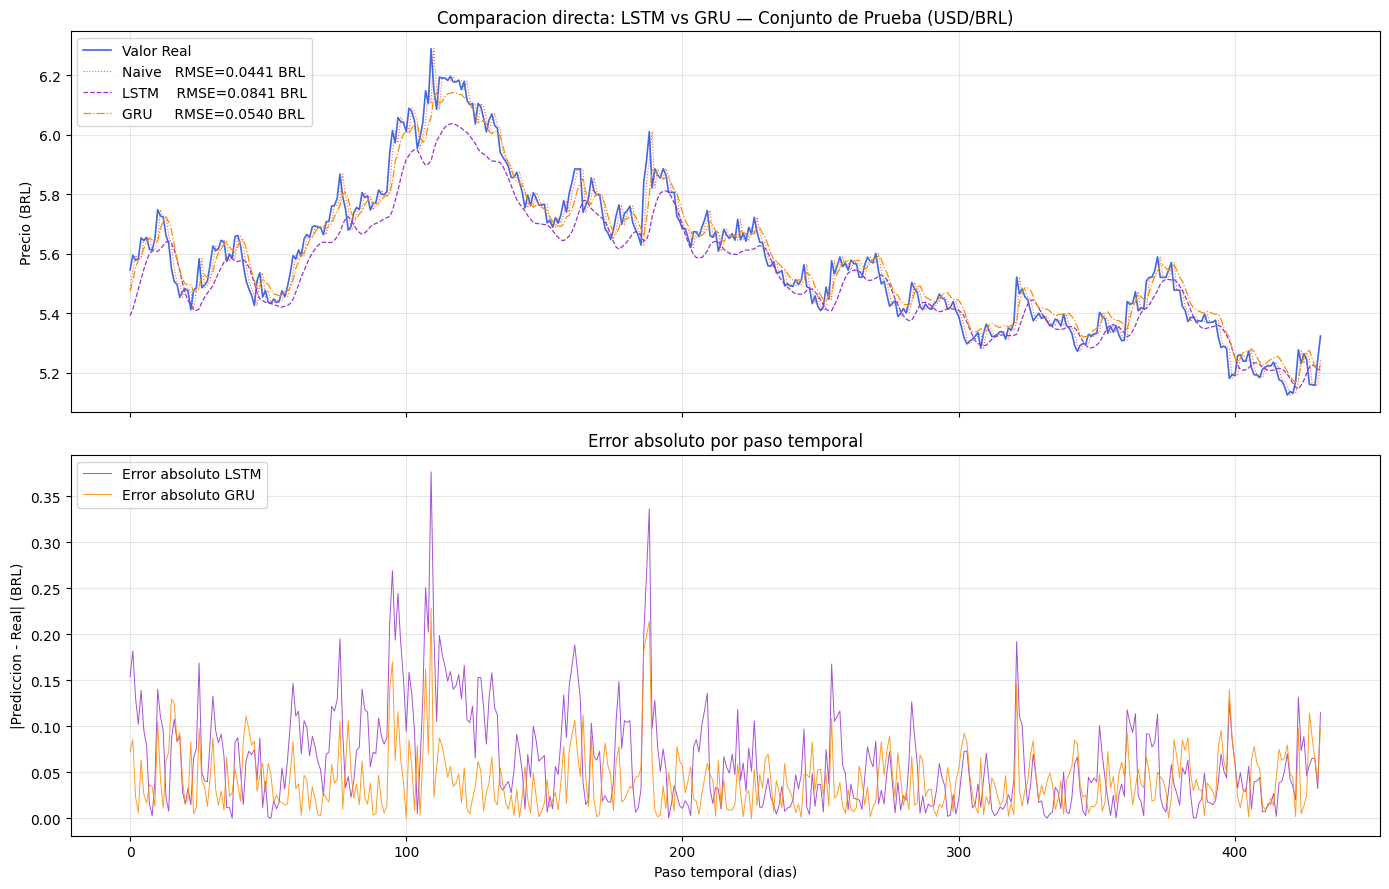

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel superior: predicciones superpuestas sobre valores reales
ax = axes[0]
ax.plot(y_test_brl,       label='Valor Real',
        color='royalblue',  linewidth=1.2, zorder=3)
ax.plot(y_pred_naive_brl, label=f'Naive   RMSE={rmse_naive:.4f} BRL',
        color='tomato',     linewidth=0.8, linestyle=':',  zorder=2)
ax.plot(y_pred_lstm_brl,  label=f'LSTM    RMSE={rmse_lstm:.4f} BRL',
        color='darkorchid', linewidth=0.9, linestyle='--', zorder=4)
ax.plot(y_pred_gru_brl,   label=f'GRU     RMSE={rmse_gru:.4f} BRL',
        color='darkorange', linewidth=0.9, linestyle='-.', zorder=4)
ax.set_title('Comparacion directa: LSTM vs GRU — Conjunto de Prueba (USD/BRL)')
ax.set_ylabel('Precio (BRL)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

# Panel inferior: error absoluto por modelo
ax2 = axes[1]
ax2.plot(np.abs(y_test_brl - y_pred_lstm_brl),
         label='Error absoluto LSTM', color='darkorchid', linewidth=0.7, alpha=0.85)
ax2.plot(np.abs(y_test_brl - y_pred_gru_brl),
         label='Error absoluto GRU',  color='darkorange',  linewidth=0.7, alpha=0.85)
ax2.set_title('Error absoluto por paso temporal')
ax2.set_xlabel('Paso temporal (dias)')
ax2.set_ylabel('|Prediccion - Real| (BRL)')
ax2.legend(loc='upper left'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

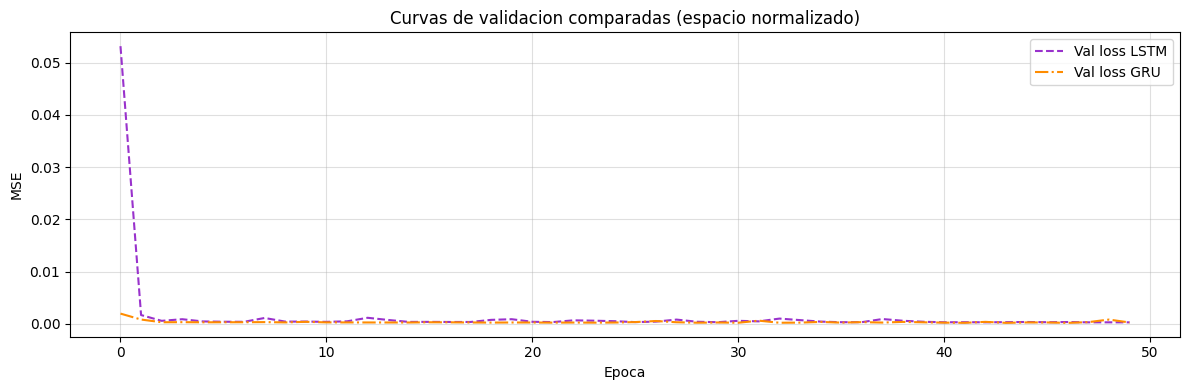

In [15]:
# Curvas de validacion comparadas
plt.figure(figsize=(12, 4))
plt.plot(hist_val_lstm, label='Val loss LSTM', color='darkorchid', linestyle='--')
plt.plot(hist_val_gru,  label='Val loss GRU',  color='darkorange',  linestyle='-.')
plt.title('Curvas de validacion comparadas (espacio normalizado)')
plt.xlabel('Epoca'); plt.ylabel('MSE')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

#### 9. Tabla de Resultados Finales

In [16]:
ahorro_pct = (1 - params_gru / params_lstm) * 100
ganador    = 'LSTM' if rmse_lstm <= rmse_gru else 'GRU'
mejor_rmse = min(rmse_lstm, rmse_gru)

sep  = '=' * 68
sep2 = '-' * 68

print(sep)
print(f'  {"TABLA COMPARATIVA FINAL --- USD/BRL":^64}')
print(sep)
print(f'  {"Modelo":<10}  {"RMSE (BRL)":>12}  {"MSE (BRL^2)":>14}  {"Parametros":>12}')
print(sep2)
print(f'  {"Naive":<10}  {rmse_naive:>12.4f}  {mse_naive:>14.6f}  {"---":>12}')
print(f'  {"LSTM":<10}  {rmse_lstm:>12.4f}  {mse_lstm:>14.6f}  {params_lstm:>12,}')
print(f'  {"GRU":<10}  {rmse_gru:>12.4f}  {mse_gru:>14.6f}  {params_gru:>12,}')
print(sep)
print(f'  Mejor modelo      : {ganador}  (RMSE = {mejor_rmse:.4f} BRL)')
print(f'  Ahorro de params  : GRU usa {ahorro_pct:.1f}% menos parametros que LSTM')
print(sep)


                TABLA COMPARATIVA FINAL --- USD/BRL               
  Modelo        RMSE (BRL)     MSE (BRL^2)    Parametros
--------------------------------------------------------------------
  Naive             0.0441        0.001943           ---
  LSTM              0.0841        0.007076        50,497
  GRU               0.0540        0.002914        37,889
  Mejor modelo      : GRU  (RMSE = 0.0540 BRL)
  Ahorro de params  : GRU usa 25.0% menos parametros que LSTM


#### 10. Conclusión: MLP vs. Modelos Recurrentes

### Comparativa de Resultados (Test)

| Arquitectura | RMSE (BRL) | Memoria Temporal |
| :--- | :---: | :--- |
| **MLP Profundo** | 0.0066 |  Nula (Trata la ventana como vector fijo) |
| **LSTM** | 0.0841 |  Alta (Estados $h_t$ y $c_t$) |
| **GRU** | **0.0540** |  Alta (Puertas *update* y *reset*) |

### Análisis Clave
* **Limitación del MLP:** Procesa los 50 días simultáneamente como un "bloque estático". Ignora el orden cronológico y la dirección de la tendencia.
* **Ventaja Recurrente (LSTM/GRU):** Procesan la secuencia **paso a paso**. Mantienen una memoria interna que detecta *momentum*, volatilidad y cambios de régimen.

> **Veredicto:** El modelo **GRU** es el ganador. Su capacidad de memoria temporal supera la estructura rígida del MLP en mercados volátiles como el USD/BRL.